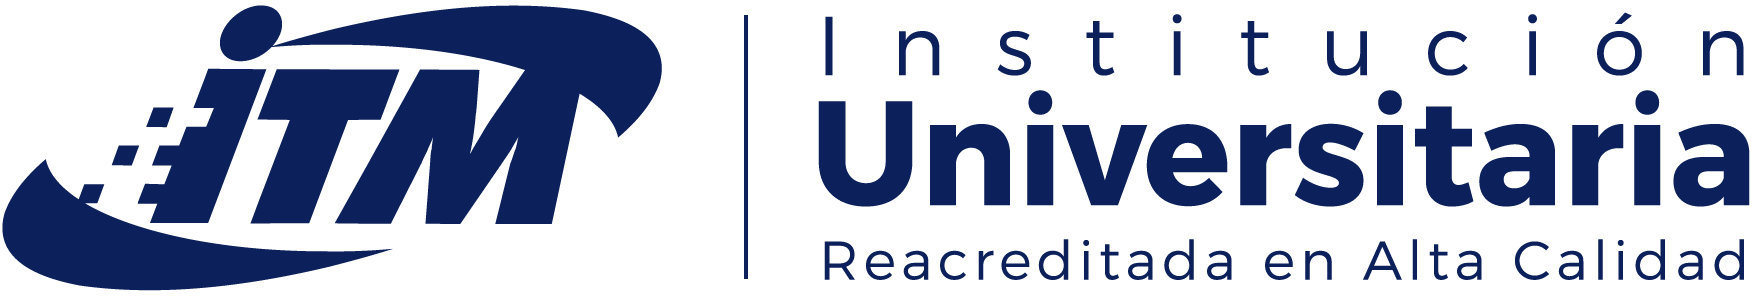

# **PROGRAMACIÓN AVANZADA**

Notebook creado por los docentes Andres Castro-Ospina y Leonardo Duque-Muñoz, modificado por los docentes Cristian Guarnizo-Lemus y Esteban Gonzalez-Valencia<br>

# **10. Matplotlib**

Módulo para visualización en Python. Está construido sobre arreglos numpy.

Existen dos formas de crear gráficos con matplotlib:

 * Usando `plt` directamente para graficar, esta forma es más rápida y es la más recomendable para empezar.
 * Usando objetos y clases, esta forma da más control.

10.1. Crear y graficar cualquier función (primero a mano)

10.2. Importar datos de un archivo externo (Ejm: Archivo de audio)

10.3. Partes de una figura

10.4. Pasos para crear un gráfico

10.5. Colores

10.6. Crear graficos interactivos

10.7. Subplots en Matplotlib

10.8. Catálogo de apariencias de Matplotlib

10.9. Crear gráficos usando y clases

In [ ]:
import numpy as np
import matplotlib.pyplot as plt   # se ha usado este alias por convención

****
## **10.1. Crear y graficar cualquier función (primero a mano)**

$ y = -4 x+7$

In [ ]:
# Tabular: damos valores a x y estimamos los correspondientes valores de y
x = np.linspace(-20,20,11)
y = -4.*x**2+7.
print(x)
print(y)

[-20. -16. -12.  -8.  -4.   0.   4.   8.  12.  16.  20.]
[-1593. -1017.  -569.  -249.   -57.     7.   -57.  -249.  -569. -1017.
 -1593.]


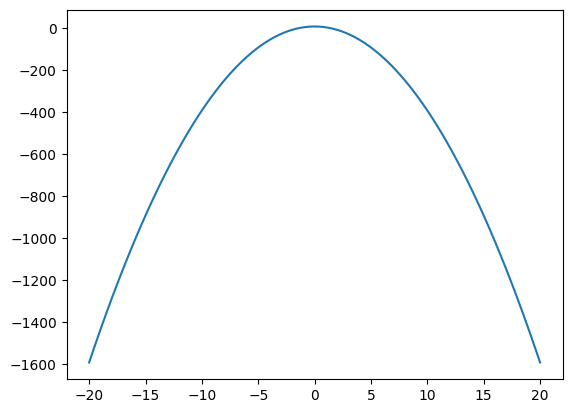

In [ ]:
plt.plot(x,y)
plt.show()

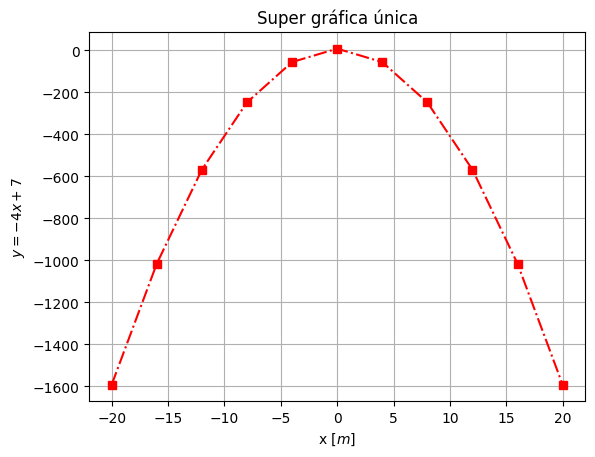

In [ ]:
plt.plot(x,y,'rs-.')                   # Graficar x vs y, 'r': rojo , 'v': simbolo tríangulo invertido, '-': línea contínua
plt.grid()                            # Cuadrícula de fondo
plt.xlabel('x [$m$]')                 # Título del eje x
plt.ylabel('$y = -4x+7$')             # Título del eje y
plt.title('Super gráfica única')      # Título del gráfico
plt.savefig('recta.pdf',dpi = 600)    # Guarda en PDF con alta resolución (300 puntos por pulgada)

Los colores básicos son:
- `b`: Azul (blue)
- `g`: Verde (green)
- `r`: Rojo (red)
- `c`: Cian (cyan)
- `m`: Magenta (magenta)
- `y`: Amarillo (yellow)
- `k`: Negro (black, se usa 'k' para no confundirlo con el azul 'b')
- `w`: Blanco

Lista de tipos de línea
- `-`: Línea continua (solid)
- `--`: Línea discontinua / guiones (dashed)
- `-.`: Línea de punto y guion (dashdot)
- `:`: Línea punteada (dotted)


Formas Geométricas Básicas
- `o`: Círculo
- `s`: Cuadrado (square)
- `D`: Diamante grande
- `d`: Diamante delgado
- `p`: Pentágono
- `h`: Hexágono (orientación 1)
- `H`: Hexágono (orientación 2)
- `8`: Octágono

Triángulos y Flechas
- `v`: Triángulo hacia abajo
- `^`: Triángulo hacia arriba
- `<`: Triángulo hacia la izquierda
- `>`: Triángulo hacia la derecha

Estrellas y Cruces
- `*`: Estrella
- `+`: Cruz en forma de suma
- `x`: Cruz en forma de multiplicación
- `X`: Cruz rellena / gruesa
- `P`: Cruz de suma rellena / gruesa

Líneas y Puntos Pequeños
- `.`: Punto pequeño
- `,`: Pixel (prácticamente invisible)
- `|`: Línea vertical
- `_`: Línea horizontal

* Creemos y grafiquemos otra función
$u = t ^2$

In [ ]:
t = np.linspace(-2.5,2.5,100)
u = t**2        #Llenar con los valores de t al cuadrado

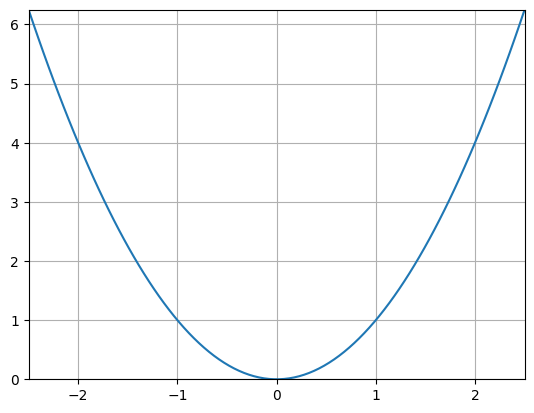

In [ ]:
plt.plot(t,u)
plt.grid()
plt.xlim([-2.5,2.5])  # Mostrar solo una sección del gráfico
plt.ylim([0,max(u)])
plt.show()


****
## **10.2. Importar datos de un archivo externo (Ejm: Archivo de audio)**


In [ ]:
!wget https://files.nostalgicplayer.dk/format/riffwave_pcm/original/CantinaBand60.wav

--2026-10-06 11:35:25--  https://files.nostalgicplayer.dk/format/riffwave_pcm/original/CantinaBand60.wav
Resolving files.nostalgicplayer.dk (files.nostalgicplayer.dk)... 185.96.183.41
Connecting to files.nostalgicplayer.dk (files.nostalgicplayer.dk)|185.96.183.41|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2646044 (2.5M) [audio/wav]
Saving to: ‘CantinaBand60.wav’

CantinaBand60.wav   100%[===================>]   2.52M  2.23MB/s    in 1.1s    

2026-10-06 11:35:27 (2.23 MB/s) - ‘CantinaBand60.wav’ saved [2646044/2646044]



In [ ]:
from scipy.io.wavfile import read
fs,y = read('CantinaBand60.wav')
print('Frecuencia de muestreo: ',fs,' Tamaño de y: ',y.size)

Frecuencia de muestreo:  22050  Tamaño de y:  1323000


In [ ]:
t = np.linspace(0,y.size/fs,y.size)

* Primero graficamos la señal en función del tiempo

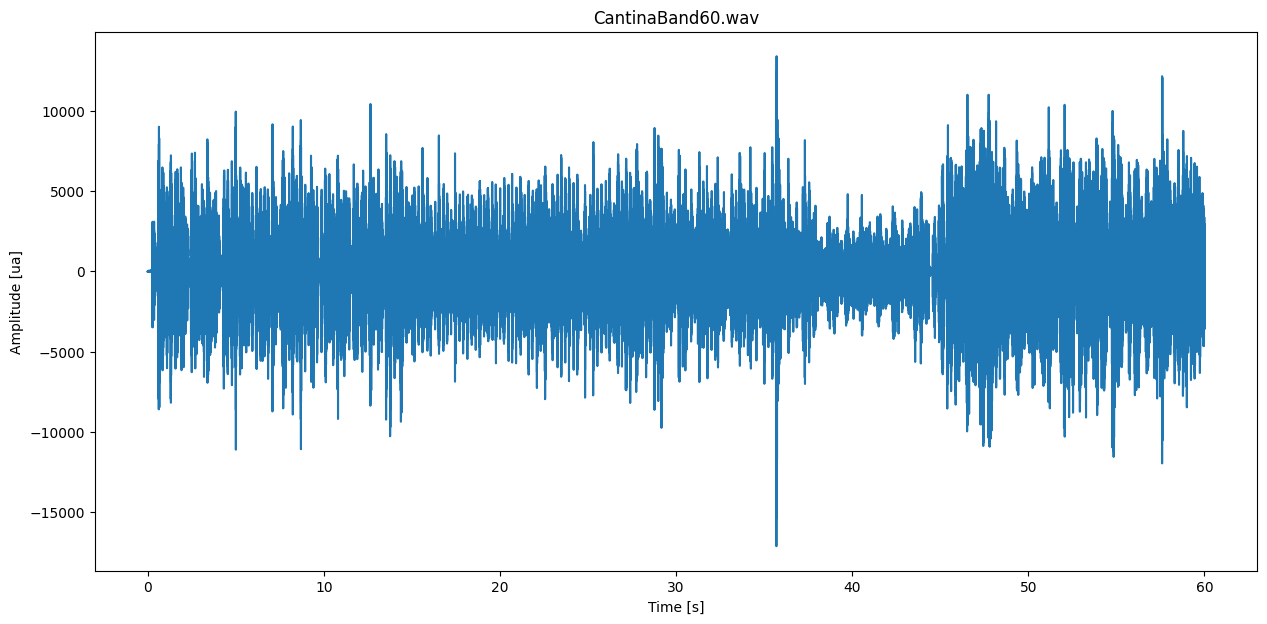

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(t,y)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [ua]')
plt.title('CantinaBand60.wav')
plt.show()

* Ahora calculamos la transformada de Fourier

El gráfic el función del tiempo  nos dice qué está pasando en cada instante, pero no nos deja ver qué frecuencias componen la señal.

La Transformada de Fourier nos permite mirar la misma señal desde otro punto de vista: en lugar de preguntarnos ¿cómo cambia con el tiempo?, nos preguntamos **¿qué frecuencias están presentes y qué tan importantes son?**”

In [ ]:
sp = np.fft.fft(y)                                          # La Transformada Rápida de Fourier
freq = np.fft.fftfreq(t.size)*fs                            # El eje de frecuencias
ind = np.where(np.bitwise_and(freq >= 0., freq < 4000. ))   # El Filtro de Interés

* Podemos graficar tanto la parte real como la imaginaria de la transformada de Fourier en una misma figura

Sintaxis básica:

  `plt.plot(x1, y1, x2, y2)`

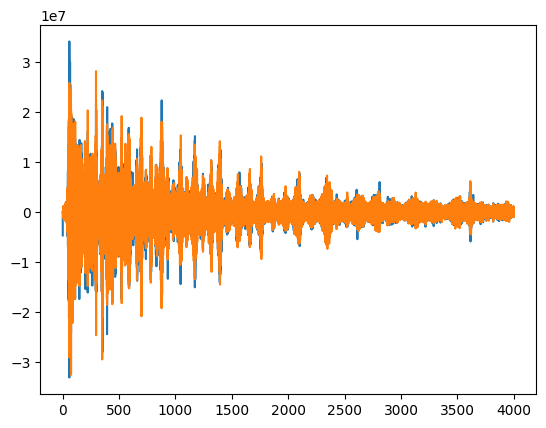

In [ ]:
plt.plot(freq[ind], sp[ind].real)
plt.plot(freq[ind], sp[ind].imag)
plt.show()

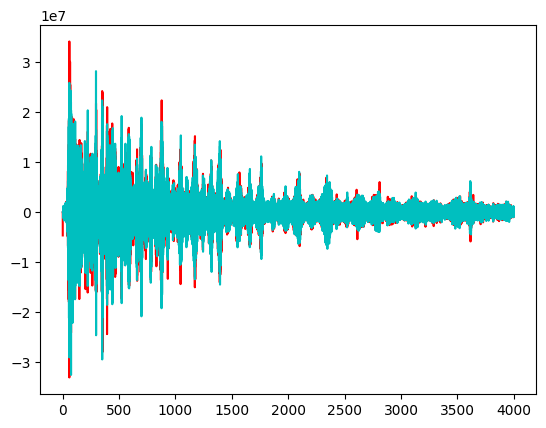

In [ ]:
plt.plot(freq[ind], sp[ind].real,'r',freq[ind], sp[ind].imag,'c')
plt.show()

* También podemos graficarlo en dos gráficos diferentes

Sintaxis básica:

`plt.subplot(n_filas, n_columnas, grafico_actual)`

`plt.subplot(x1, y1)`

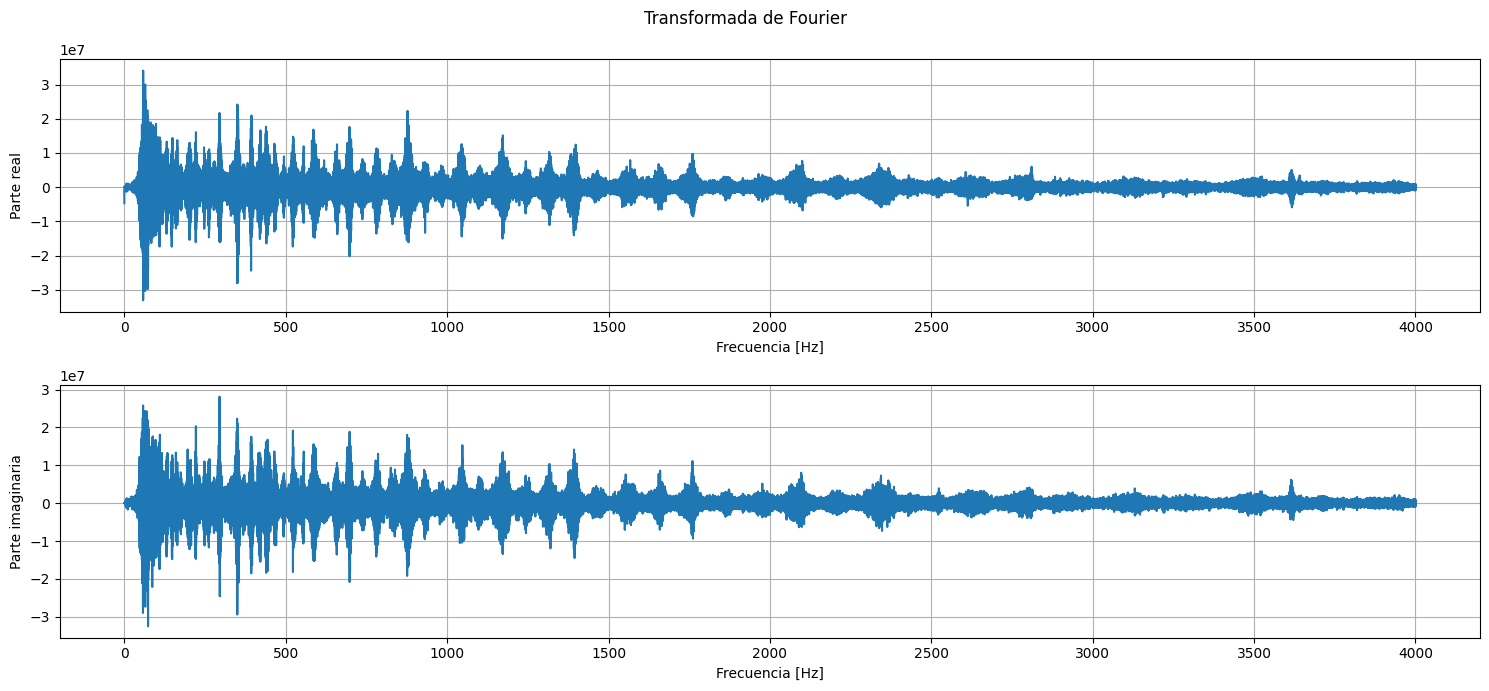

In [ ]:
plt.figure(figsize=(15, 7))
plt.suptitle('Transformada de Fourier')

# Primera subfigura
plt.subplot(2, 1, 1)
plt.plot(freq[ind], sp[ind].real)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Parte real')
plt.grid()

# Segunda subfigura
plt.subplot(2, 1, 2)
plt.plot(freq[ind], sp[ind].imag)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Parte imaginaria')
plt.grid()

plt.tight_layout()
plt.show()

* Otra forma de hacerlo:

Sintaxis básica:

`fig, (graph_1, graph_2, graph_n, ...) = plt.subplots(n_filas, n_columnas)`

`graph_1.plot(x1,y1)`

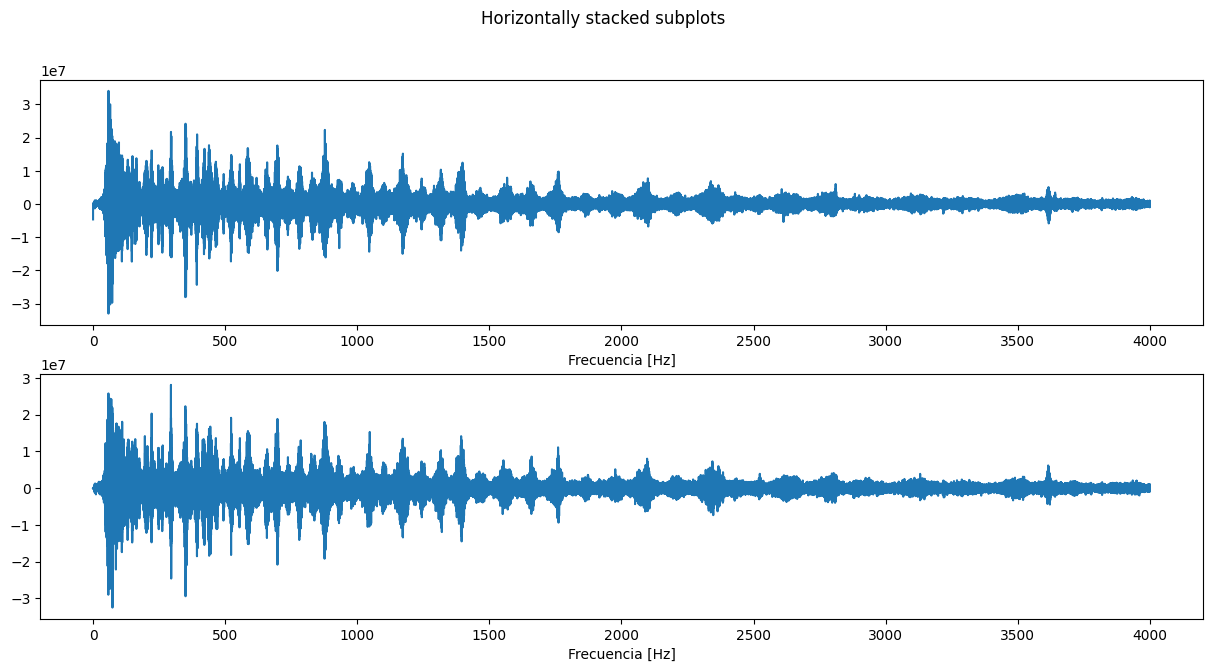

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7))       # Se van a graficar las subfiguras ax1 y ax2
fig.suptitle('Horizontally stacked subplots')               # Título de la figura (completa)

ax1.plot(freq[ind], sp[ind].real)                           # Primera subfigura
ax1.set_xlabel('Frecuencia [Hz]')                           # Título de la subfigura ax1

ax2.plot(freq[ind], sp[ind].imag)
ax2.set_xlabel('Frecuencia [Hz]')
plt.show()

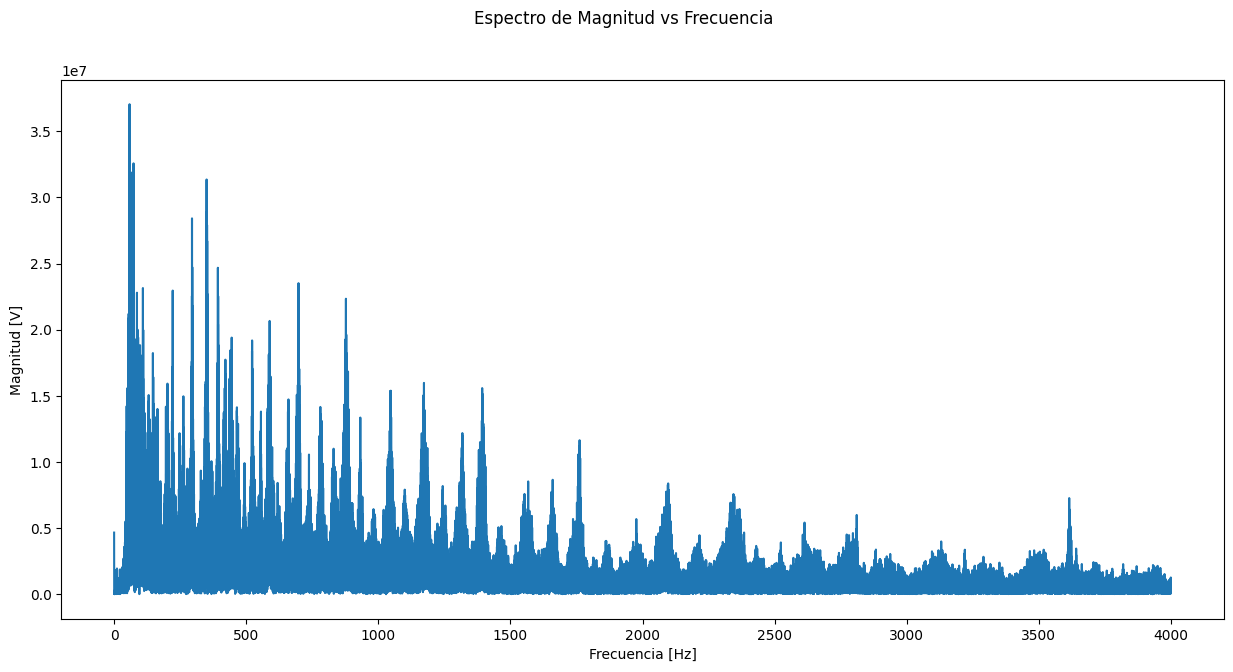

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(15, 7))
fig.suptitle('Espectro de Magnitud vs Frecuencia')
ax1.plot(freq[ind], np.abs(sp[ind]))
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('Magnitud [V]')
plt.show()

****
## **10.3. Partes de una figura**
### Tomado de https://matplotlib.org/stable/gallery/showcase/anatomy.html

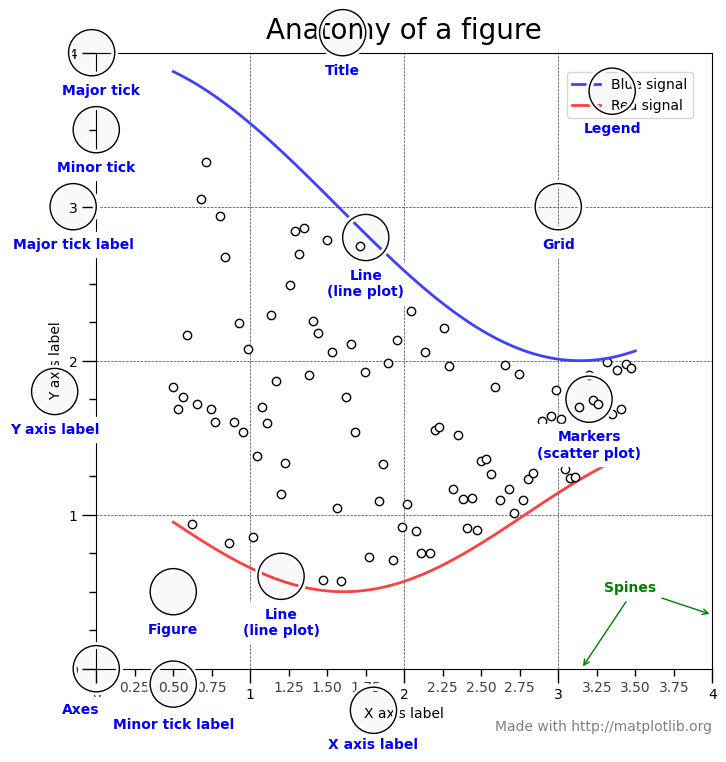

In [ ]:
# This figure shows the name of several matplotlib elements composing a figure

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter


np.random.seed(19680801)

X = np.linspace(0.5, 3.5, 100)
Y1 = 3+np.cos(X)
Y2 = 1+np.cos(1+X/0.75)/2
Y3 = np.random.uniform(Y1, Y2, len(X))

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, aspect=1)


def minor_tick(x, pos):
    if not x % 1.0:
        return ""
    return "%.2f" % x

ax.xaxis.set_major_locator(MultipleLocator(1.000))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_locator(MultipleLocator(1.000))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_formatter(FuncFormatter(minor_tick))

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

ax.tick_params(which='major', width=1.0)
ax.tick_params(which='major', length=10)
ax.tick_params(which='minor', width=1.0, labelsize=10)
ax.tick_params(which='minor', length=5, labelsize=10, labelcolor='0.25')

ax.grid(linestyle="--", linewidth=0.5, color='.25', zorder=-10)

ax.plot(X, Y1, c=(0.25, 0.25, 1.00), lw=2, label="Blue signal", zorder=10)
ax.plot(X, Y2, c=(1.00, 0.25, 0.25), lw=2, label="Red signal")
ax.plot(X, Y3, linewidth=0,
        marker='o', markerfacecolor='w', markeredgecolor='k')

ax.set_title("Anatomy of a figure", fontsize=20, verticalalignment='bottom')
ax.set_xlabel("X axis label")
ax.set_ylabel("Y axis label")

#ax.legend()
ax.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98))

def circle(x, y, radius=0.15):
    from matplotlib.patches import Circle
    from matplotlib.patheffects import withStroke
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=1,
                    edgecolor='black', facecolor=(0, 0, 0, .0125),
                    path_effects=[withStroke(linewidth=5, foreground='w')])
    ax.add_artist(circle)


def text(x, y, text):
    ax.text(x, y, text, backgroundcolor="white",
            ha='center', va='top', weight='bold', color='blue')


# Minor tick
circle(0.50, -0.10)
text(0.50, -0.32, "Minor tick label")

# Major tick
circle(-0.03, 4.00)
text(0.03, 3.80, "Major tick")

# Minor tick
circle(0.00, 3.50)
text(0.00, 3.30, "Minor tick")

# Major tick label
circle(-0.15, 3.00)
text(-0.15, 2.80, "Major tick label")

# X Label
circle(1.80, -0.27)
text(1.80, -0.45, "X axis label")

# Y Label
circle(-0.27, 1.80)
text(-0.27, 1.6, "Y axis label")

# Title
circle(1.60, 4.13)
text(1.60, 3.93, "Title")

# Blue plot
circle(1.75, 2.80)
text(1.75, 2.60, "Line\n(line plot)")

# Red plot
circle(1.20, 0.60)
text(1.20, 0.40, "Line\n(line plot)")

# Scatter plot
circle(3.20, 1.75)
text(3.20, 1.55, "Markers\n(scatter plot)")

# Grid
circle(3.00, 3.00)
text(3.00, 2.80, "Grid")

# Legend
#circle(3.70, 3.80)
#text(3.70, 3.60, "Legend")
circle(3.35, 3.75)  # Movido un poco a la izquierda y abajo para centrarlo en la caja
text(3.35, 3.55, "Legend")

# Figure Axes.old
circle(0.5, 0.5)
text(0.5, 0.3, "Figure")

# Axes
circle(0, 0)
text(-0.1, -0.22, "Axes")

color = 'green'
ax.annotate('Spines', xy=(4.0, 0.35), xycoords='data',
            xytext=(3.3, 0.5), textcoords='data',
            weight='bold', color=color,
            arrowprops=dict(arrowstyle='->',
                            connectionstyle="arc3",
                            color=color))

ax.annotate('', xy=(3.15, 0.0), xycoords='data',
            xytext=(3.45, 0.45), textcoords='data',
            weight='bold', color=color,
            arrowprops=dict(arrowstyle='->',
                            connectionstyle="arc3",
                            color=color))

ax.text(4.0, -0.4, "Made with http://matplotlib.org",
        fontsize=10, ha="right", color='.5')

plt.show()

*****

## **10.4. Pasos para crear un gráfico**

Sin importar cómo se cree el gráfico (usando plt o usando objetos y clases), para generar un gráfico, se deben seguir los siguientes 5 pasos:

  1. __Preparar los datos que se desean graficar__
  2. __Crear o construir una figura__: una figura es el contenedor para cualquier tipo de gráfico que se quiera generar con matplotlib.pyplot.
  3. __Graficar (de ser necesario construir un área de dibujo)__: estas áreas se conocen como axes, ya que definen los ejes para el gráfico y la forma de proyectar los datos en este.
  4. __Personalizar el gráfico__: matplotlib.pyplot permite la personalización de muchos aspectos de un gráfico.
  5. __Mostrar o guardar el gráfico__


In [ ]:
help(plt.figure)

  ### __10.4.1. Preparar los datos que se desean graficar__

In [ ]:
# 1. Preparar los datos que se desean graficar
t = np.linspace(-2.5,2.5,100)
u = t**2 #Llenar con los valores de t al cuadrado

  ### __10.4.2. Crear o construir una figura__

`figsize` = (ancho en pulgadas, alto en pulgadas)

`dpi` = número entero que define puntos por pulgada (resolución de imagen)

In [ ]:
plt.figure(figsize=(14,4), dpi=300) # , facecolor='lightgray'

  ### __10.4.3. Graficar__

`linewidth` = Ajustar el ancho de la línea

`alpha` = Ajustar la transparencia

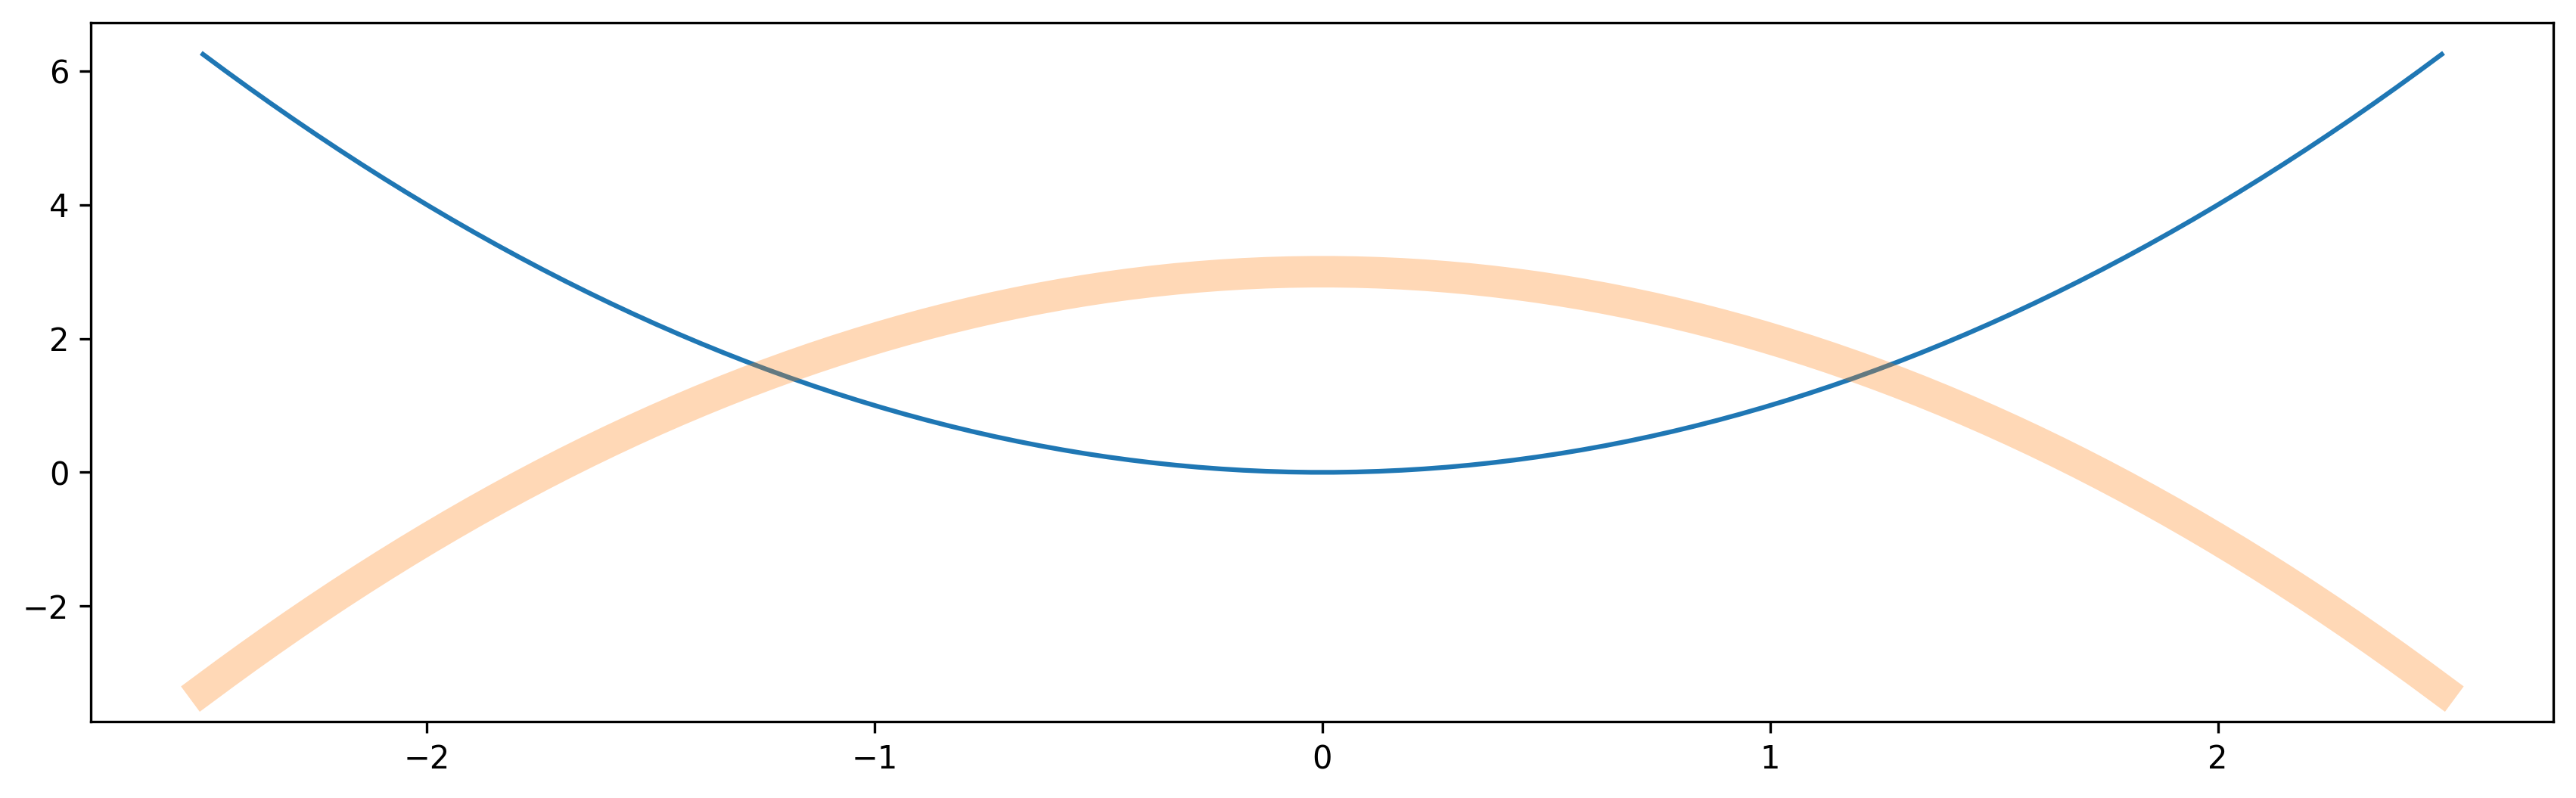

In [ ]:
plt.figure(figsize=(14,4), dpi=300)
plt.plot(t,u)
plt.plot(t,-u+3, linewidth=10, alpha=0.3)

plt.show()

  ### __10.4.4. Personalizar el gráfico__

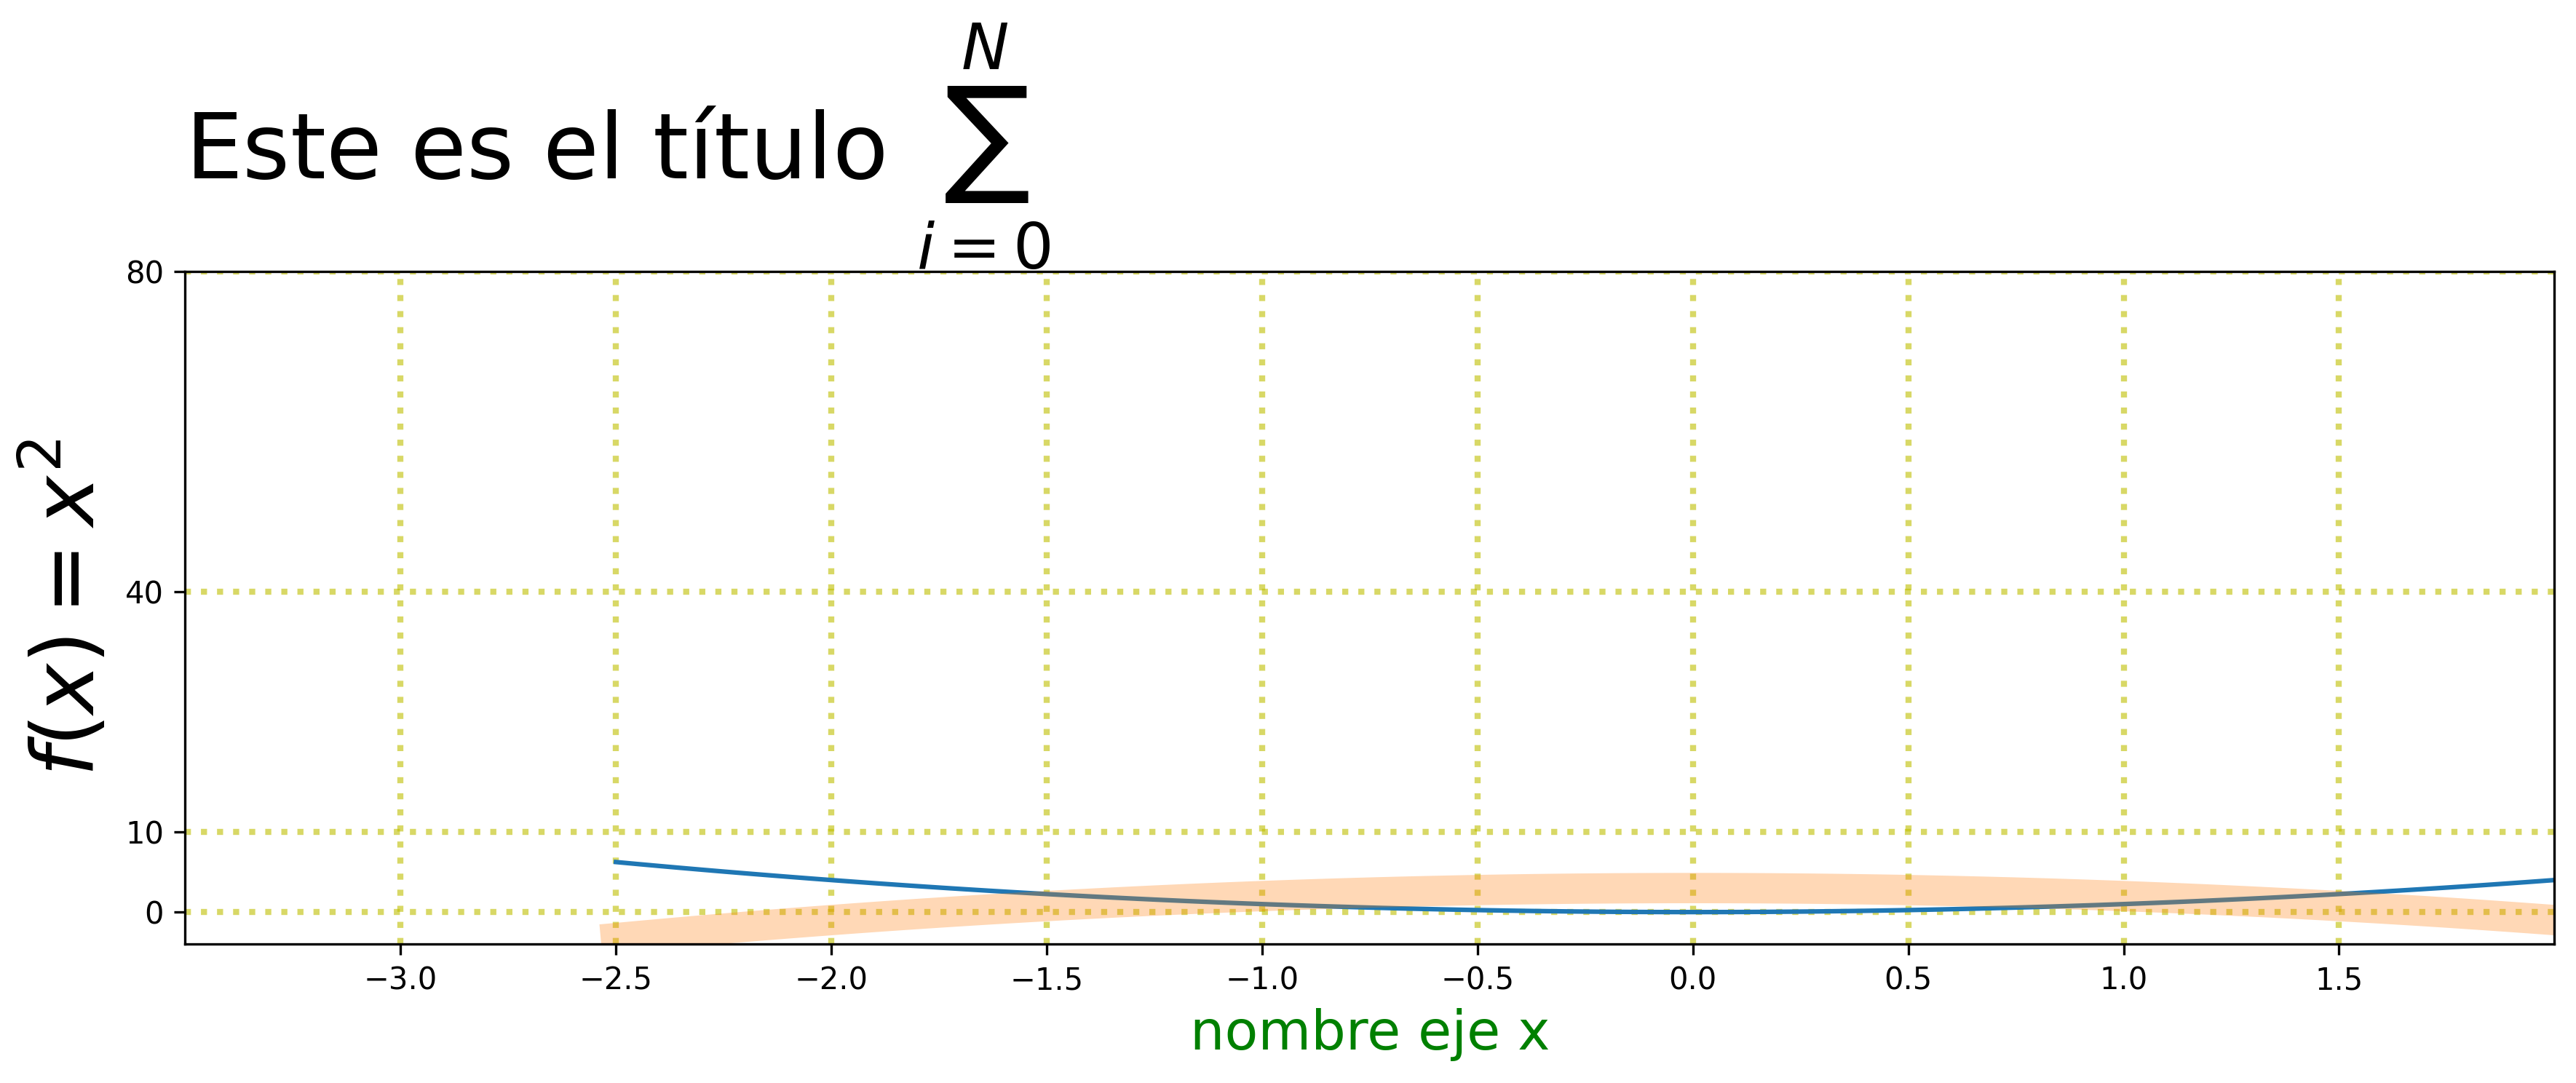

In [ ]:
# 4. Personalizar el gráfico
plt.figure(figsize=(14,4), dpi=300)
plt.plot(t,u)
plt.plot(t,-u+3, linewidth=10, alpha=0.3)

##  Agregar un título, con tamaño y ubicación personalizada
plt.title(r"Este es el título $\sum_{i=0}^{N}$",fontsize=30, loc='left')
##  Agregar una Cuadrícula de fondo, con color, tipo de línea y transparencia personalizada
# plt.grid()
plt.grid(axis = 'both', color='y',linestyle = ':', linewidth=2, alpha=0.6)

#plt.xlim([-3.5,1]) # Limitar los limites del gráfico
plt.axis([-3.5, 2, -4, 20]) # plt.axis([limiteinfx, limitesupx, infy, supy])
plt.yticks([0,10,40,80])     # Personalizar marcas en los ejes
plt.xticks(np.arange(-3,2,0.5))
#plt.yticks([])               # Apagar (quitar) yticks
#plt.xticks([])               # Apagar (quitar) xticks
#plt.axis('off')              # Quitar los ejes

plt.ylabel('$f(x)= x^2$',fontsize=28)
plt.xlabel('nombre eje x',fontsize=18, color='g')
plt.show()

  ### __10.4.5. Guardar el gráfico__

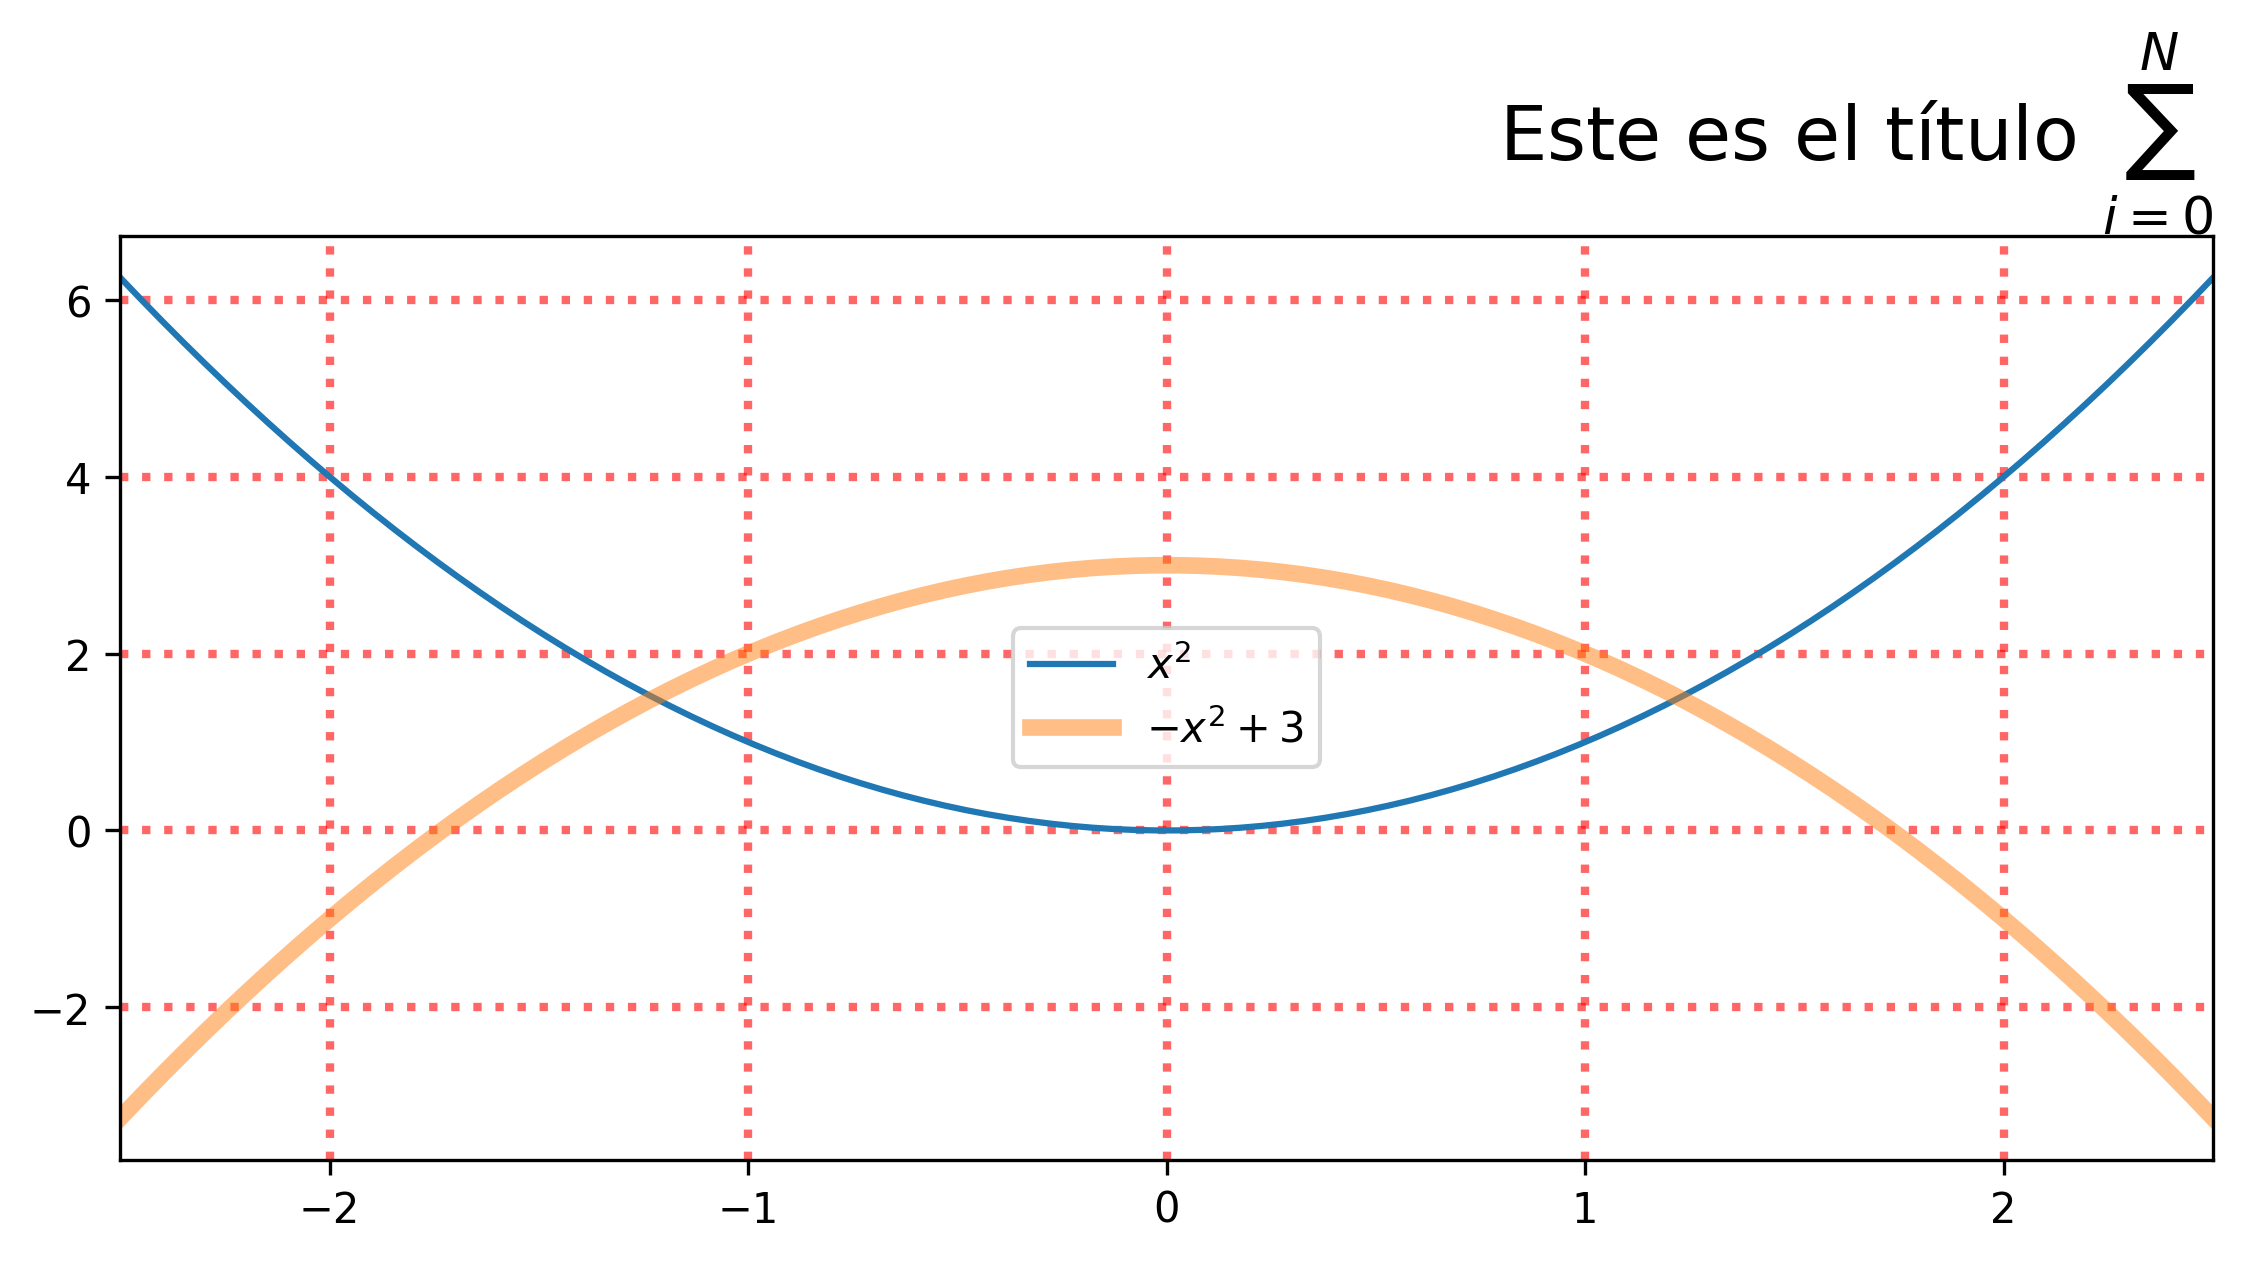

In [ ]:
plt.figure(figsize=(9,4), dpi=300)
plt.plot(t,u)
plt.plot(t,-u+3, linewidth=4, alpha=0.5)
plt.title(r"Este es el título $\sum_{i=0}^{N}$",fontsize=18, pad=12, loc='right')
plt.grid(axis = 'both', color='r',linestyle = ':', linewidth=2, alpha=0.6)
plt.xlim([-2.5,2.5])

plt.savefig('FiguraCreada.png', dpi=600, transparent=True)  # transparent=True)
plt.legend(['$x^2$','$-x^2+3$'], loc = 'center')              # Agregar Leyenda (comparar la figura mostrada y la guardada)

plt.show()

  ### __10.4.6. Personalizar otras propiedades__

* Personalizar los 'tick labels' de los ejes

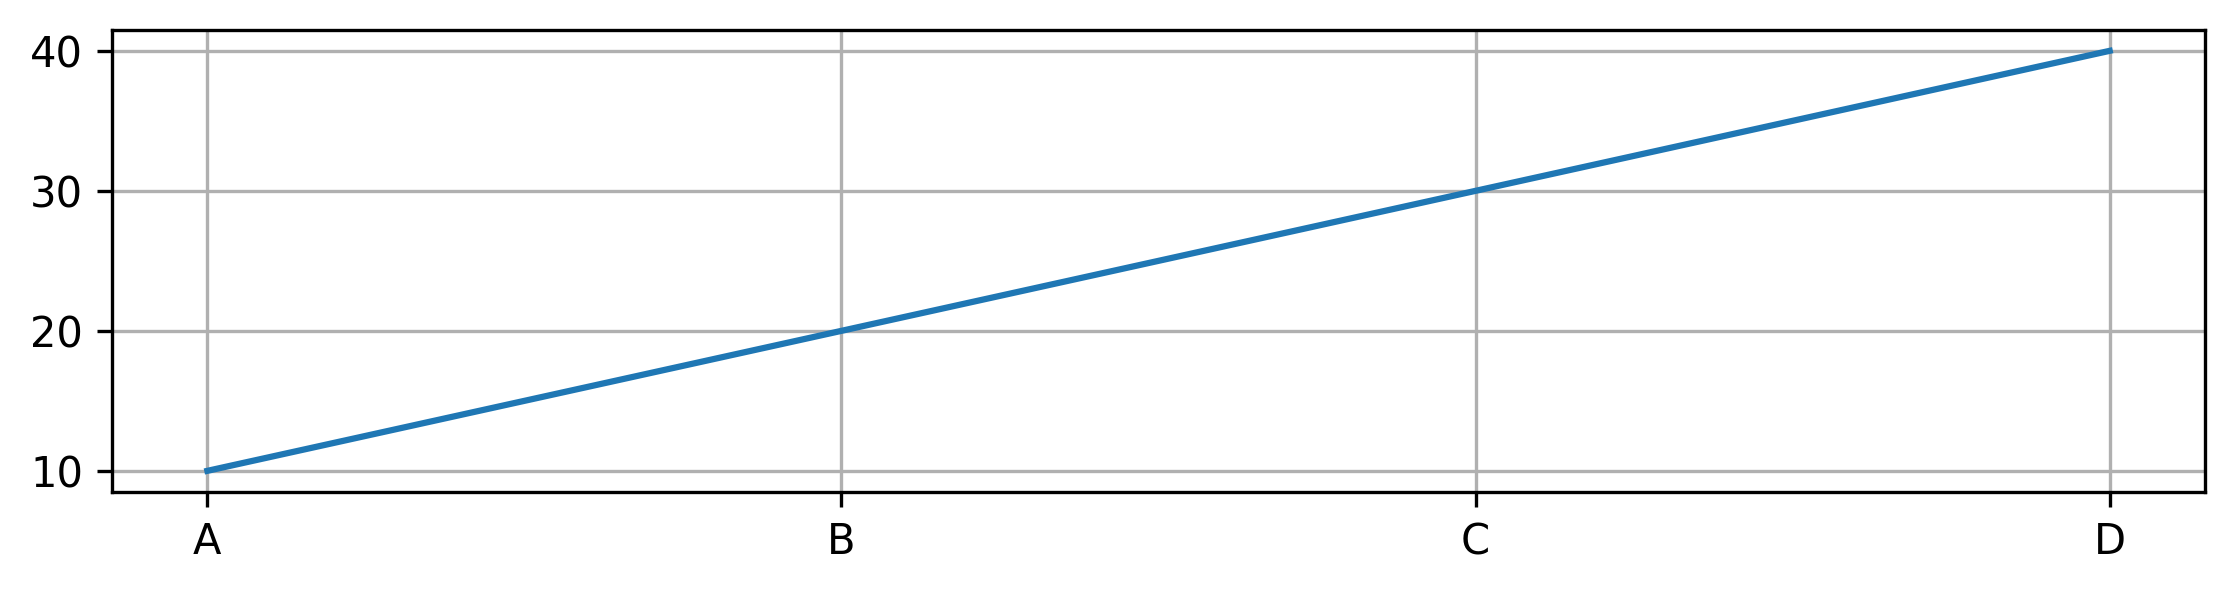

In [ ]:
plt.figure(figsize=(9,2), dpi=300)
plt.plot([10, 20, 30, 40]) #Toma los x como el índice (posición)
plt.xticks([0,1,2,3],['A', 'B', 'C', 'D']);
plt.yticks([10, 20, 30, 40]);
plt.grid()

In [ ]:
# Valores de 0 a 3 con pasos de 0.2
t = np.arange(-3, 3.1, 0.2)
t

array([-3.00000000e+00, -2.80000000e+00, -2.60000000e+00, -2.40000000e+00,
       -2.20000000e+00, -2.00000000e+00, -1.80000000e+00, -1.60000000e+00,
       -1.40000000e+00, -1.20000000e+00, -1.00000000e+00, -8.00000000e-01,
       -6.00000000e-01, -4.00000000e-01, -2.00000000e-01,  2.66453526e-15,
        2.00000000e-01,  4.00000000e-01,  6.00000000e-01,  8.00000000e-01,
        1.00000000e+00,  1.20000000e+00,  1.40000000e+00,  1.60000000e+00,
        1.80000000e+00,  2.00000000e+00,  2.20000000e+00,  2.40000000e+00,
        2.60000000e+00,  2.80000000e+00,  3.00000000e+00])

* Personalizar la leyenda de los gráficos

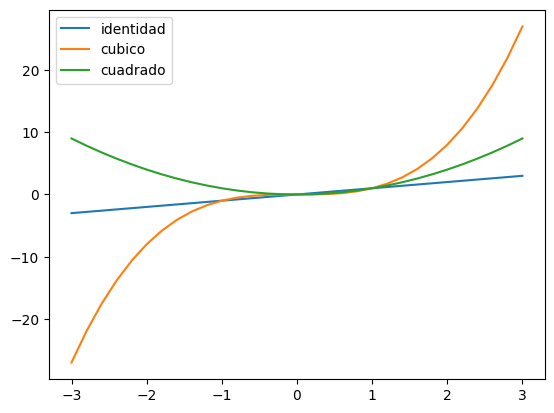

In [ ]:
plt.figure()
plt.plot(t, t, t, t**3, t, t**2 )
plt.legend(['identidad','cubico','cuadrado'])

plt.show()

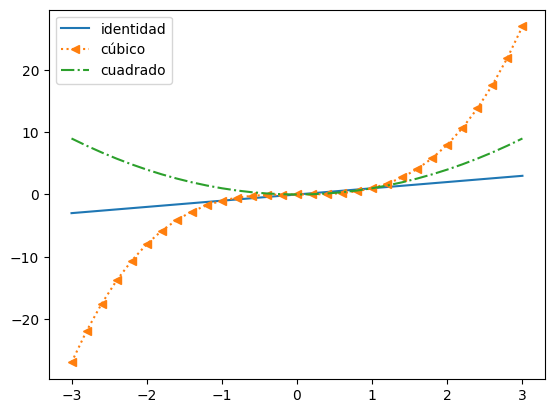

In [ ]:
plt.figure()
plt.plot(t, t,label='identidad')
plt.plot(t, t**3,'<:',label='cúbico')
plt.plot(t, t**2,'-.', label='cuadrado')

plt.legend()

plt.show()

* Personalizar los marcadores de los gráficos

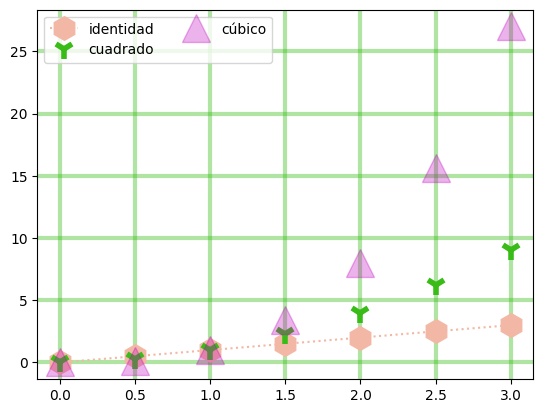

In [ ]:
t = np.arange(0, 3.1, 0.5)
plt.figure()
#plt.plot(t, t)
#plt.plot(t, t, ':k*', label='identidad', markersize=12)      #color, linewidth, marker, markersize, linestyles
plt.plot(t, t, color='#F3B8A5', linestyle=':', marker='h', label='identidad', markersize=17)

#plt.plot(t, t**2)
plt.plot(t, t**2, '1', color='#39BC18',label='cuadrado', markersize=14, markeredgewidth=4)
#plt.plot(t, t**2, color='c', marker = '2', linestyle=' ', label='cuadrado', markersize=12,markeredgewidth=2)

#plt.plot(t, t**3)
plt.plot(t, t**3, 'm^', label='cúbico', markersize = 20, alpha = 0.3)
#plt.plot(t, t**3, color='green', marker='^', linestyle=':', label='cúbico', markersize=13)

plt.legend()
#plt.legend(loc='center')
plt.legend(ncol=2)
plt.grid()
#plt.grid(color=(73/255, 97/255, 249/255, 0.8) , linestyle='-',linewidth=3)
plt.grid(color='#39BC18' , linestyle='-',linewidth=3, alpha=0.4)
#plt.grid(color='0.8' , linestyle='-.',linewidth=2)
plt.show()

## **10.5. Colores**

El argumento de color se puede dar de las siguientes maneras
- Uno de los colores básicos {'b', 'g', 'r', 'c', 'm', 'y', 'k', 'w'}
- Una tupla de valores flotantes de RGB o RGBA en el rango [0,1]. Por ejemplo: (0.2, 0.5, 0.8) o (0.2, 0.5, 0.8, 0.4)
- Un string hexadecimal de RGB o RGBA (e.g., '#0f0f0f' or '#0f0f0f80'; es case-insensitive);
- Una representación string de un valor flotante en el rango [0,1] para niveles de gris, por ejemplo: '0.8'

#### **Ejemplo**

Graficar el seno y coseno de 0 a 4$\pi$ en un mismo gráfico y con marcadores, colores, estilos de línea diferentes.


In [ ]:
pi = np.pi

A = np.arange(0, 4*pi, 0.1)
sen = np.sin(A)
cos = np.cos(A)

plt.figure()
plt.plot(A, sen, color='0.5', linestyle = '-', label='seno')
#plt.plot(A, sen, color='#8E0C25', linestyle = '--', label='seno',linewidth = 5)
#plt.plot(A, cos, color=(180/255, 27/255, 168/255), label='coseno', linestyle = '-')
#plt.xticks([0,pi, 2*pi, 3*pi, 4*pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$',r'$4\pi$'], fontsize=18)
plt.grid(axis = 'y', color='k', linewidth=0.5)
plt.legend()
plt.show()


****
## **10.6. Crear graficos interactivos**

Usando `matplotlib` se crean imágenes estáticas (como una foto). `Plotly` permite crear gráficos interactivos.

In [ ]:
import plotly.graph_objects as go
fig = go.Figure( go.Scatter(x=freq[ind], y=np.abs(sp[ind]) ) )
fig.show()

****
## **10.7. Subplots en Matplotlib**

Hay varias formas de hacer esto. En esta clase se utilizará el método de agregar subplots.

Cada figura puede contener varios gráficos, esta puede ser dividida en varias filas y columnas para asignar un área de dibujo a cada celda o elemento de la rejilla resultante. Para esto se utiliza la función *plt.subplot*; esta función recibe 3 argumentos. El primero es el número de filas, el segundo el número de columnas y el tercero, la posición en donde se asignará el área de dibujo.

In [ ]:
help(plt.subplot)

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(2,1,1)
plt.text(0.36,0.5,"Gráfico 1", fontsize=16)

plt.subplot(2,1,2)
plt.text(0.36,0.5,"Gráfico 2", fontsize=16)

plt.show()

***
### **Ejercicio**

Graficar el seno y coseno de 0 a 4$\pi$ en diferentes gráficos y con marcadores, colores, estilos y tamaños de línea diferentes.

In [ ]:
# Escriba el código para calcular los datos que va a graficar:


In [ ]:
# Celda solución
plt.figure(figsize=(15,4))

plt.subplot(2,1,1)
plt.plot(A, sen, color='0.2', linestyle = '--', label='seno')
plt.grid(axis = 'both', color='k', linewidth=0.5)
plt.xticks([0,pi, 2*pi, 3*pi, 4*pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$',r'$4\pi$'], fontsize=18)
plt.legend()

plt.subplot(2,1,2)
plt.plot(A, cos, color=(180/255, 27/255, 168/255), label='coseno', linestyle = '-')
plt.legend()
plt.xticks([0,pi, 2*pi, 3*pi, 4*pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$',r'$4\pi$'], fontsize=18)
plt.grid(axis = 'both', color='k', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.plot(A, sen, color='0.2', linestyle = '--', label='seno')
plt.grid(axis = 'both', color='k', linewidth=0.5)
plt.xticks([0,pi, 2*pi, 3*pi, 4*pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$',r'$4\pi$'], fontsize=18)
plt.legend()

plt.subplot(122)
plt.plot(A, cos, color=(180/255, 27/255, 168/255), label='coseno', linestyle = '-')
plt.legend()
plt.xticks([0,pi, 2*pi, 3*pi, 4*pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$',r'$4\pi$'], fontsize=18)
plt.grid(axis = 'both', color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
x = np.arange(0,4*np.pi,0.2)
c = np.cos(x)
s = np.sin(x)
t = np.tan(x)

plt.figure(figsize=(15,12))
plt.subplot(2,2,1)
plt.plot(x,s,marker='.', color='red', label='Señal Seno')
plt.grid()
plt.xticks([0,np.pi, 2*np.pi, 3*np.pi, 4*np.pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$'], fontsize=18)
plt.legend()

plt.subplot(2,2,2)
plt.plot(x,c,color = '#205C91', linestyle='-.', linewidth=4, label='Señal Coseno')
plt.grid()
plt.xticks([0,np.pi, 2*np.pi, 3*np.pi, 4*np.pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$'], fontsize=18)
plt.legend()

plt.subplot(2,1,2)
plt.plot(x,t,color = '#FF5C91', linestyle='-.', linewidth=4, label='Señal Tangente')
plt.grid()
plt.xticks([0,np.pi, 2*np.pi, 3*np.pi, 4*np.pi],[0,r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$'], fontsize=18)
plt.legend()
plt.savefig("FiguraSub.png")

****
## **10.8. Catálogo de apariencias de Matplotlib**

Son útiles para para que no tener que configurar manualmente cada color, grosor de línea o tipo de fuente. Una vez que se elige un nombre de esa lista, lo aplicas con el comando

In [ ]:
plt.style.available

In [ ]:
plt.style.use("Solarize_Light2")
plt.figure(figsize=(15,4))

plt.style.use("ggplot")
plt.subplot(1,2,1)
plt.plot(A, sen, color='0.2', linestyle = '--', label='seno')
plt.legend()

plt.style.use("dark_background")
plt.subplot(122)

plt.plot(A, cos, color=(180/255, 27/255, 168/255), label='coseno', linestyle = '-')
plt.legend()
plt.show()

In [ ]:
plt.style.use("default")

****
## **10.9. Crear gráficos usando y clases**

 La ventaja de usar objetos y clases para crear gráficos con matplotlib consiste que de esta forma se tiene más control.

 En esta segunda forma, las figuras y axes (gráficos) son objetos, por lo tanto para interactuar con ellos se hace con métodos.

 * Primero crearemos un gráfico como hemos visto hasta ahora

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(x, s, 'r--s', label='Prueba')
plt.ylim(-2, 2)
plt.xlim(-1, 15)
plt.grid()
plt.legend()
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.title('Título', fontsize=14)
plt.savefig("graficoSinObjetos.png", dpi=400)

* Ahora crearemos el mismo gráfico usando objetos:

In [ ]:
fig = plt.figure(figsize=(6,3))               # Crea el objeto contenedor principal (la ventana o lienzo).
ax = fig.add_subplot(111)                     # Crea el objeto "ejes" (la gráfica individual) dentro de la figura.
ax.plot(x, s, 'r--s', label='Prueba')         # Dibuja los datos en los ejes: rojo, línea punteada y cuadrados.
ax.set_ylim((-2, 2))                          # Define el límite inferior y superior del eje vertical (y).
ax.set_xlim((-1, 15))                         # Define el límite inicial y final del eje horizontal (x).
ax.grid()                                     # Activa la cuadrícula de fondo para facilitar la lectura.
ax.legend()                                   # Muestra el cuadro de leyenda usando el 'label' definido en plot.
ax.set_xlabel('x', fontsize=14)               # Establece la etiqueta del eje x y ajusta su tamaño de fuente.
ax.set_ylabel('y', fontsize=14)               # Establece la etiqueta del eje y y ajusta su tamaño de fuente.
ax.set_title('Título', fontsize=14)           # Define el título principal que aparece arriba de la gráfica.
plt.tight_layout()                            # Ajusta automáticamente los márgenes para que nada se encime.
fig.savefig("graficoConObjetos.png", dpi=400) # Guarda la figura en un archivo con alta resolución (400 ppp).

**¿Cuál de los dos deberías usar?**

* __Estilo Funcional (plt):__

Es perfecto para scripts rápidos, análisis de datos al vuelo en cuadernos de Jupyter o gráficas muy sencillas donde solo hay un dibujo. Es más rápido de escribir pero se vuelve caótico si tienes muchas ventanas abiertas.

* __Estilo Objetos (fig, ax):__

Es el estándar profesional. Es indispensable cuando quieres hacer subtramas (varias gráficas en una sola imagen) o cuando estás programando una aplicación donde necesitas tener control total sobre qué elemento estás modificando en cada momento.

| Característica | Estilo Funcional (`plt.`) | Estilo Orientado a Objetos (`ax.`) |
| :--- | :--- | :--- |
| **Filosofía** | Basado en el "estado actual" (global). | Basado en instancias específicas (local). |
| **Creación inicial** | `plt.figure(figsize=(w,h))` | `fig, ax = plt.subplots(figsize=(w,h))` |
| **Título principal** | `plt.title('...')` | `ax.set_title('...')` |
| **Etiqueta eje X** | `plt.xlabel('...')` | `ax.set_xlabel('...')` |
| **Etiqueta eje Y** | `plt.ylabel('...')` | `ax.set_ylabel('...')` |
| **Límites de ejes** | `plt.xlim([min, max])` | `ax.set_xlim(min, max)` |
| **Ubicación de tics** | `plt.xticks([0, 1, 2])` | `ax.set_xticks([0, 1, 2])` |
| **Texto de los tics** | `plt.xticks(lista, etiquetas)` | `ax.set_xticklabels(etiquetas)` |
| **Leyenda** | `plt.legend()` | `ax.legend()` |
| **Cuadrícula (Grid)** | `plt.grid()` | `ax.grid()` |
| **Dibujar datos** | `plt.plot(x, y)` | `ax.plot(x, y)` |
| **Múltiples gráficas** | `plt.subplot(filas, cols, índice)` | `fig, (ax1, ax2) = plt.subplots(1, 2)` |
| **Ajuste de diseño** | `plt.tight_layout()` | `fig.tight_layout()` |
| **Guardar imagen** | `plt.savefig('nombre.png')` | `fig.savefig('nombre.png')` |

***
### **Ejercicio**

Graficar el seno y coseno de 0 a 4$\pi$ en un mismo gráfico y con marcadores, colores, estilos de línea diferentes. Luego graficarlo en diferentes gráficos

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(A, sen, color='0.4', linestyle = '--', label='seno')
ax.plot(A, cos, color=(180/255, 27/255, 168/255), label='coseno', linestyle = '-')
ax.set_xticks([0,pi, 2*pi, 3*pi, 4*pi])
ax.grid(axis = 'y', color='k', linewidth=0.5)
ax.set_xticklabels([0,r'$\pi$', r'$2\pi$', r'$3\pi$',r'$4\pi$'])
ax.legend()
plt.show()

In [ ]:
np.sum(cos*sen)

In [ ]:
# plt.xkcd()

fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.plot(A, sen, color='0.4', linestyle = '--', label='seno')
ax2.plot(A, cos, color=(180/255, 27/255, 168/255), label='coseno', linestyle = '-')
ax1.set_xticks([0,pi, 2*pi, 3*pi, 4*pi])
ax1.grid(axis = 'y', color='k', linewidth=0.5)
ax1.set_xticklabels([0,r'$\pi$', r'$2\pi$', r'$3\pi$',r'$4\pi$'])
ax2.legend()
plt.show()


In [ ]:
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

plt.scatter('a', 'b', c='c', s='d', data=data)
plt.xlabel('entry a')
plt.ylabel('entry b')
plt.show()

## [Tutorial de Pyplot](https://matplotlib.org/stable/tutorials/introductory/pyplot.html)


## Ejemplos:
https://matplotlib.org/3.1.1/tutorials/introductory/sample_plots.html

In [ ]:
def paraboloide(x,y):
    return x**2 + y**2

In [ ]:
%matplotlib notebook

from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt


fig = plt.figure()
#ax = fig.gca(projection='3d')
ax = fig.add_subplot(111, projection='3d')

# FXY = lambda x,y: x**2+y**2

X = np.arange(-5, 5, 0.2)
Y = np.arange(-5, 5, 0.2)
# XX, YY = np.meshgrid(X, Y)

R = np.zeros((len(X),len(Y)))
XX = np.zeros((len(X),len(Y)))
YY = np.zeros((len(X),len(Y)))

for i in range(len(X)):
    for j in range(len(Y)):
        R[i,j] = paraboloide(X[i],Y[j])
        XX[i,j] = X[i]
        YY[i,j] = Y[j]

surf = ax.plot_surface(XX, YY, R,cmap='jet',alpha=0.3)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np # <-- No olvides esta línea

# Definimos la función
paraboloide = lambda x, y: x**2 + y**2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # <-- Cambio clave

# Creamos los datos de forma eficiente
x = np.arange(-5, 5, 0.2)
y = np.arange(-5, 5, 0.2)
XX, YY = np.meshgrid(x, y) # Esto crea las rejillas automáticamente
R = paraboloide(XX, YY)    # Aplicamos la función a toda la matriz a la vez

# Graficamos
surf = ax.plot_surface(XX, YY, R, cmap='jet', alpha=0.3)
plt.show()

#### Con Matplotlib se puede hacer mucho más!
### ver https://matplotlib.org/stable/tutorials/index.html